# Tuned ElasticNet Regression Model


In [ ]:
import sys, os
sys.path.insert(0, '../src')
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skrub import TableReport
import joblib, os
import preprocess
import explore
import model
import model_elasticnet
from sklearn.preprocessing import PowerTransformer
os.environ['PYTHONWARNINGS'] = 'ignore'

# Path for storing results
MODEL_DIR = os.path.abspath('../models')


In [ ]:
# Running through preprocessing steps
df_im, df_cl = explore.load_data()

# Clean datasets
_im_id_cols = ['Patient', 'Timepoint', 'Date']
df_im_vis   = preprocess.clean_im(df_im, False)
df_cl_vis   = preprocess.clean_cl(df_cl, False)

# Immunological: drop >25% NaN columns, remove confirmed outliers
df_im_mod    = preprocess.remove_nan_cols(df_im_vis, verbose=False)
df_im_mod    = preprocess.remove_outlier_observations(df_im_mod, verbose=False)
df_im_mod    = preprocess.remove_for_modeling(df_im_mod, verbose=False)
# Clinical: drop >25% NaN columns
df_cl_mod    = preprocess.remove_nan_cols(df_cl_vis, verbose=False)
df_cl_mod    = preprocess.remove_for_modeling(df_cl_mod, verbose=False)

df_im_mod : (814, 77)
df_cl_mod : (842, 26)


# Modeling with (T1-T2) immunological data


In [ ]:
# Creating Target
print('\nConstructing regression targets from clinical data')
pain_targets       = model.construct_datasets_targets(df_cl_mod, 'pain_scale',      [1, 2])

# Constructing dataset for modeling with targets and im + cl data
print('\nConstructing datasets for modeling:')
df_pain = model.create_model_datasets(df_im_mod, df_cl_mod, pain_targets, timepoints=[1, 2])


Constructing regression targets from clinical data

  Target distributions:
    pain_reduction                              mean=1.347  std=2.051  [-4.000, 7.100]
    pain_reduction_pct                          mean=19.196  std=32.847  [-100.000, 87.654]

  Target distributions:
    pain_under_load_reduction                   mean=0.551  std=0.753  [-1.000, 3.000]
    pain_under_load_reduction_pct               mean=14.125  std=20.231  [-50.000, 75.000]


## Dataset Overview

In [ ]:
TableReport(df_pain, max_plot_columns=100)


Constructing datasets for modeling:

Total Number of Clinical features: 24
  Dropping 7 Columns before modeling: ['morning_stiffness', 'pain_at_rest', 'pain_daytime', 'pain_night', 'pain_scale', 'pain_under_load', 'response']
  Dropped baseline target cols : ['pain_scale_t1']

Modeling datasets ready: (T1–T2 immunological data + clinical baseline variables:
Shape of Combined Dataset: (116, 95), Number of Patients: 116

Total Number of Clinical features: 24
  Dropping 7 Columns before modeling: ['morning_stiffness', 'pain_at_rest', 'pain_daytime', 'pain_night', 'pain_scale', 'pain_under_load', 'response']
  Dropped baseline target cols : ['pain_under_load_t1']

Modeling datasets ready: (T1–T2 immunological data + clinical baseline variables:
Shape of Combined Dataset: (115, 95), Number of Patients: 115


## Elasticnet + MRMR Feature selection 
### Nested CV and Optuna hyperparameter tuning

### Target: pain_reduction_pct

In [ ]:
import model_elasticnet
pt = PowerTransformer(method='yeo-johnson', standardize=True)

en_mrmr_results_df, en_feature_freq = model_elasticnet.elasticnet_mrmr(
        df_pain,
        target_col='pain_reduction_pct',
        random_state=42,
        target_transformer=pt)

# Save results and feature frequency list
joblib.dump(en_mrmr_results_df,      os.path.join(MODEL_DIR, 'en_results_df.pkl'))
joblib.dump(en_feature_freq,         os.path.join(MODEL_DIR, 'en_feature_freq.pkl'))



  CatBoost + Optuna + MRMR — pain_reduction
  n=116, p=92, K=15
  Outer 4×5=20 | Inner 4×5=20 | Model trials=50

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
  MRMR Selected: 15/92 features — ['CD123lo Bas_t2_minus_t1', 'T8lo_t2_minus_t1', 'NK4_t2_minus_t1', 'mDC-1_t2_minus_t1', 'NKT_56+/16+_t2_minus_t1', 'T_CD25+_t2_minus_t1', 'TH_CD25hi_t2_minus_t1', 'Mo_HLADRhi_t2_minus_t1']...
    Trial   1/50: RMSE=1.0052  {'depth': 5, 'learning_rate': 0.23705688269828706, 'l2_leaf_reg': 1.3227908237200787, 'bagging_temperature': 0.31181848267981704}
    Trial   2/50: RMSE=0.9757  {'depth': 8, 'learning_rate': 0.004237260412327668, 'l2_leaf_reg': 1.4941744192199742, 'bagging_temperature': 0.7069343163430255}
    Trial   3/50: RMSE=0.9963  {'depth': 5, 'learning_rate': 0.22379901358345242, 'l2_leaf_reg': 6.843001068876014, 'bagging_temperature': 0.683434887910986}
    Trial   4/50: RMSE=0.9788 

[W 2026-03-19 02:35:42,315] Trial 31 failed with parameters: {'depth': 6, 'learning_rate': 0.007378813252362511, 'l2_leaf_reg': 5.9073372428090885, 'bagging_temperature': 0.8705565266131519} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\mufa\.conda\envs\mt26\lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "p:\UK_Erlangen\Student_folders\Muna Ahmed Farah - IMMO-LDRT01\master-thesis\notebooks\../src\model_catboost_mrmr.py", line 172, in model_objective
    rmses = joblib.Parallel(n_jobs=-1, prefer='threads')(
  File "c:\Users\mufa\.conda\envs\mt26\lib\site-packages\joblib\parallel.py", line 2072, in __call__
    return output if self.return_generator else list(output)
  File "c:\Users\mufa\.conda\envs\mt26\lib\site-packages\joblib\parallel.py", line 1682, in _get_outputs
    yield from self._retrieve()
  File "c:\Users\mufa\.conda\envs\mt26\lib\site-packages\joblib\pa

KeyboardInterrupt: 

## Plot of Feature Frequency List 
Top 20 Features Selections Shown.

In [ ]:
feature_list = joblib.load(os.path.join(MODEL_DIR, 'en_feat_freq.pkl'))
model.plot_feature_frequency(feature_list, name='ElasticNet (pain_reduction_pct)', top=20)

## ElasticNet on Different Subsets of Selected Features

In [ ]:
en_sweep_df = model_elasticnet.elasticnet_threshold_analysis(
     df_pain, 
     feature_list, 
     target_col='pain_reduction_pct',
     random_state=42, 
     target_transformer=pt)
joblib.dump(en_sweep_df,      os.path.join(MODEL_DIR, 'en_sweep_df.pkl'))


# Plot performances on different feature-tresholds
model.plot_sweep(en_sweep_df, name='ElasticNet: Performance Metrics vs. n Features')

## Final ElasticNet Model 
### Using Features Selected in More Than 8/20 Outer Folds

In [ ]:
en_feature_freq = joblib.load(os.path.join(MODEL_DIR, 'en_feature_freq'))
# selecting features in more than ../20 outer folds:
sel_features = en_feature_freq[en_feature_freq >= 8].index.tolist()

en_model, en_X_final, en_y_pred, en_patient_err, en_scaler = model_elasticnet.run_tuned_elasticnet(
    df_pain, 
    sel_features,
    target_col='pain_reduction_pct', 
    random_state=42,
    target_transformer=pt)

# save results
joblib.dump(en_model,                os.path.join(MODEL_DIR, 'en_model.pkl'))
joblib.dump(en_X_final,              os.path.join(MODEL_DIR, 'en_X_final.pkl'))
joblib.dump(en_patient_err,          os.path.join(MODEL_DIR, 'en_patient_err.pkl'))
joblib.dump(en_scaler,               os.path.join(MODEL_DIR, 'en_scaler.pkl'))

## Difficult Patient-Predictions

In [ ]:
patient_err = joblib.load(os.path.join(MODEL_DIR, 'en_patient_err.pkl'))
print(patient_err.to_string())

In [ ]:
# Pain Values for top 10 difficult patient predictions:
difficult_patients = en_patient_err.head(10).index.tolist()

pain_data = (df_cl_mod[df_cl_mod['Patient'].isin(difficult_patients)]
             [['Patient', 'Timepoint', 'pain_scale']].pivot(index='Patient', columns='Timepoint', values='pain_scale'))
pain_data.columns = [f'pain_t{c}' for c in pain_data.columns]

difficult_df = (pain_data
                .merge(en_patient_err[['mean_mae']], left_index=True, right_index=True)
                .sort_values('mean_mae', ascending=False))

print('Difficult Patient-Predictions and Pain Scale Values:')
display(difficult_df)

## SHAP-values Plot

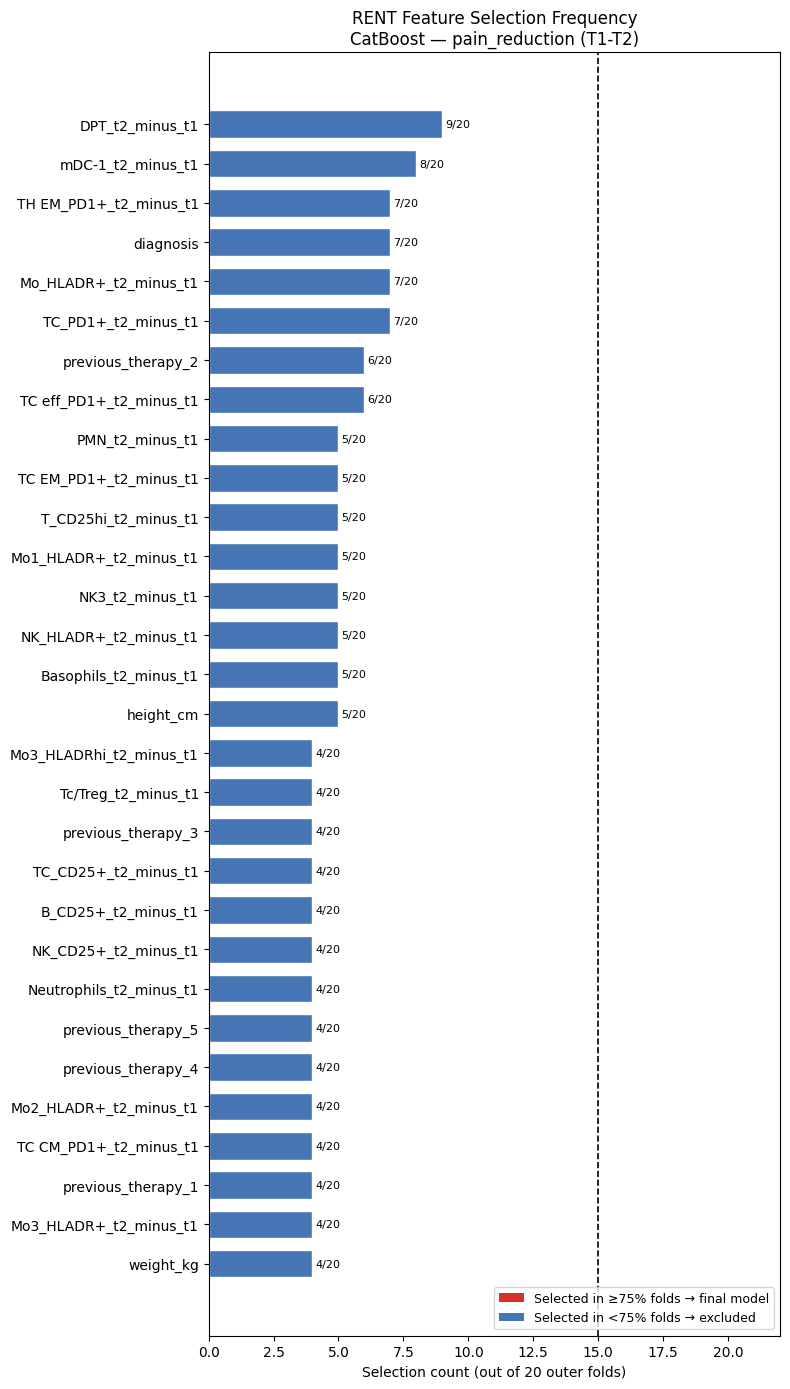


 SHAP — CatBoost (pain_reduction, T1-T2)

=== SHAP Analysis: CatBoost — pain_reduction (T1-T2) ===


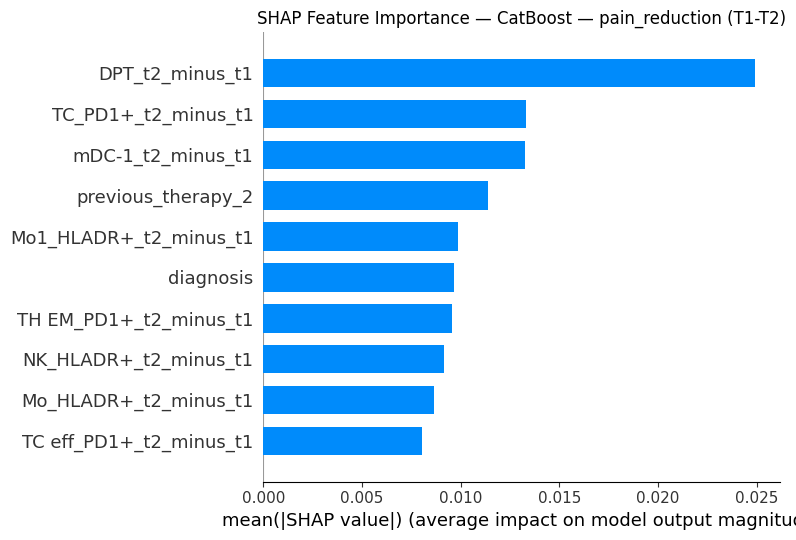

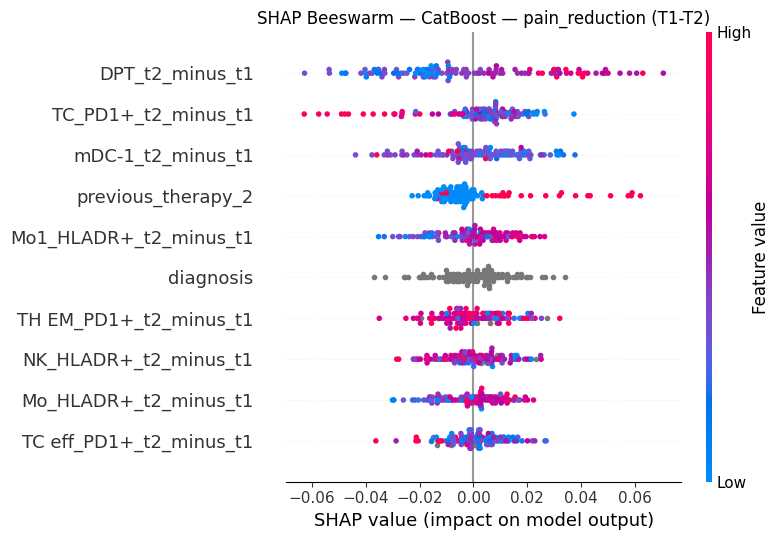

In [ ]:
# Plot Shap values
en_model= joblib.load(os.path.join(MODEL_DIR, 'en_model.pkl'))
en_X_final = joblib.load(os.path.join(MODEL_DIR, 'en_X_final.pkl'))
en_scaler = joblib.load(os.path.join(MODEL_DIR, 'en_scaler.pkl'))

en_shap = model.plot_shap_elasticnet(en_model, en_X_final, en_scaler)


# _____________________________________________________________________
# Modeling with T2 immunological data 

In [ ]:
# Modeling using only T2 immunological data
# Creating Target
print('\nConstructing regression targets from clinical data')
pain_targets       = model.construct_datasets_targets(df_cl_mod, 'pain_scale',      [1, 2])

# Constructing dataset for modeling 
print('\nConstructing datasets for modeling:')
df_pain = model.create_model_datasets(df_im_mod, df_cl_mod, pain_targets, timepoints=[2])

## Dataset Overview

In [ ]:
TableReport(df_pain, max_plot_columns=100)


Constructing datasets for modeling:

Total Number of Clinical features: 24
  Dropping 7 Columns before modeling: ['morning_stiffness', 'pain_at_rest', 'pain_daytime', 'pain_night', 'pain_scale', 'pain_under_load', 'response']
  Dropped baseline target cols : ['pain_scale_t1']

Modeling datasets ready: (T1–T2 immunological data + clinical baseline variables:
Shape of Combined Dataset: (116, 95), Number of Patients: 116

Total Number of Clinical features: 24
  Dropping 7 Columns before modeling: ['morning_stiffness', 'pain_at_rest', 'pain_daytime', 'pain_night', 'pain_scale', 'pain_under_load', 'response']
  Dropped baseline target cols : ['pain_under_load_t1']

Modeling datasets ready: (T1–T2 immunological data + clinical baseline variables:
Shape of Combined Dataset: (115, 95), Number of Patients: 115


## Elasticnet + MRMR Feature selection 
### Nested CV and Optuna hyperparameter tuning

In [ ]:
import model_elasticnet
pt = PowerTransformer(method='yeo-johnson', standardize=True)

en2_mrmr_results_df, en2_feature_freq = model_elasticnet.elasticnet_mrmr(
        df_pain,
        target_col='pain_reduction_pct',
        random_state=42,
        target_transformer=pt)

# Save results and feature frequency list
joblib.dump(en2_mrmr_results_df,      os.path.join(MODEL_DIR, 'en2_results_df.pkl'))
joblib.dump(en2_feature_freq,         os.path.join(MODEL_DIR, 'en2_feature_freq.pkl'))



  CatBoost + Optuna + MRMR — pain_reduction
  n=116, p=92, K=15
  Outer 4×5=20 | Inner 4×5=20 | Model trials=50

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
  MRMR Selected: 15/92 features — ['CD123lo Bas_t2_minus_t1', 'T8lo_t2_minus_t1', 'NK4_t2_minus_t1', 'mDC-1_t2_minus_t1', 'NKT_56+/16+_t2_minus_t1', 'T_CD25+_t2_minus_t1', 'TH_CD25hi_t2_minus_t1', 'Mo_HLADRhi_t2_minus_t1']...
    Trial   1/50: RMSE=1.0052  {'depth': 5, 'learning_rate': 0.23705688269828706, 'l2_leaf_reg': 1.3227908237200787, 'bagging_temperature': 0.31181848267981704}
    Trial   2/50: RMSE=0.9757  {'depth': 8, 'learning_rate': 0.004237260412327668, 'l2_leaf_reg': 1.4941744192199742, 'bagging_temperature': 0.7069343163430255}
    Trial   3/50: RMSE=0.9963  {'depth': 5, 'learning_rate': 0.22379901358345242, 'l2_leaf_reg': 6.843001068876014, 'bagging_temperature': 0.683434887910986}
    Trial   4/50: RMSE=0.9788 

[W 2026-03-19 02:35:42,315] Trial 31 failed with parameters: {'depth': 6, 'learning_rate': 0.007378813252362511, 'l2_leaf_reg': 5.9073372428090885, 'bagging_temperature': 0.8705565266131519} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\mufa\.conda\envs\mt26\lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "p:\UK_Erlangen\Student_folders\Muna Ahmed Farah - IMMO-LDRT01\master-thesis\notebooks\../src\model_catboost_mrmr.py", line 172, in model_objective
    rmses = joblib.Parallel(n_jobs=-1, prefer='threads')(
  File "c:\Users\mufa\.conda\envs\mt26\lib\site-packages\joblib\parallel.py", line 2072, in __call__
    return output if self.return_generator else list(output)
  File "c:\Users\mufa\.conda\envs\mt26\lib\site-packages\joblib\parallel.py", line 1682, in _get_outputs
    yield from self._retrieve()
  File "c:\Users\mufa\.conda\envs\mt26\lib\site-packages\joblib\pa

KeyboardInterrupt: 

## Plot of Feature Frequency List 
Top 20 Features Selections Shown.

In [ ]:
feature_list2 = joblib.load(os.path.join(MODEL_DIR, 'en2_feat_freq.pkl'))
model.plot_feature_frequency(feature_list2, name='ElasticNet (pain_reduction_pct)', top=20)

## ElasticNet on Different Subsets of Selected Features

In [ ]:
en2_sweep_df = model_elasticnet.elasticnet_threshold_analysis(
     df_pain, 
     feature_list2, 
     target_col='pain_reduction_pct',
     random_state=42, 
     target_transformer=pt)
joblib.dump(en2_sweep_df,      os.path.join(MODEL_DIR, 'en2_sweep_df.pkl'))


# Plot performances on different feature-tresholds
model.plot_sweep(en2_sweep_df, name='ElasticNet: Performance Metrics vs. n Features')

## Final ElasticNet Model 
### Using Features Selected in More Than 8/20 Outer Folds

In [ ]:
feature_freq = joblib.load(os.path.join(MODEL_DIR, 'en2_feature_freq'))
# selecting features in more than ../20 outer folds:
sel_features = feature_freq[feature_freq >= 8].index.tolist()

en2_model, en2_X_final, en2_y_pred, en2_patient_err, en2_scaler = model_elasticnet.run_tuned_elasticnet(
    df_pain, 
    sel_features,
    target_col='pain_reduction_pct', 
    random_state=42,
    target_transformer=pt)

# save results
joblib.dump(en2_model,                os.path.join(MODEL_DIR, 'en2_model.pkl'))
joblib.dump(en2_X_final,              os.path.join(MODEL_DIR, 'en2_X_final.pkl'))
joblib.dump(en2_patient_err,          os.path.join(MODEL_DIR, 'en2_patient_err.pkl'))
joblib.dump(en2_scaler,               os.path.join(MODEL_DIR, 'en2_scaler.pkl'))

## Difficult Patient-Predictions

In [ ]:
patient_err = joblib.load(os.path.join(MODEL_DIR, 'en2_patient_err.pkl'))
print(patient_err.to_string())

In [ ]:
# Pain Values for top 10 difficult patient predictions:
difficult_patients = patient_err.head(10).index.tolist()

pain_data = (df_cl_mod[df_cl_mod['Patient'].isin(difficult_patients)]
             [['Patient', 'Timepoint', 'pain_scale']].pivot(index='Patient', columns='Timepoint', values='pain_scale'))
pain_data.columns = [f'pain_t{c}' for c in pain_data.columns]

difficult_df = (pain_data
                .merge(patient_err[['mean_mae']], left_index=True, right_index=True)
                .sort_values('mean_mae', ascending=False))

print('Difficult Patient-Predictions and Pain Scale Values:')
display(difficult_df)

## SHAP-values Plot

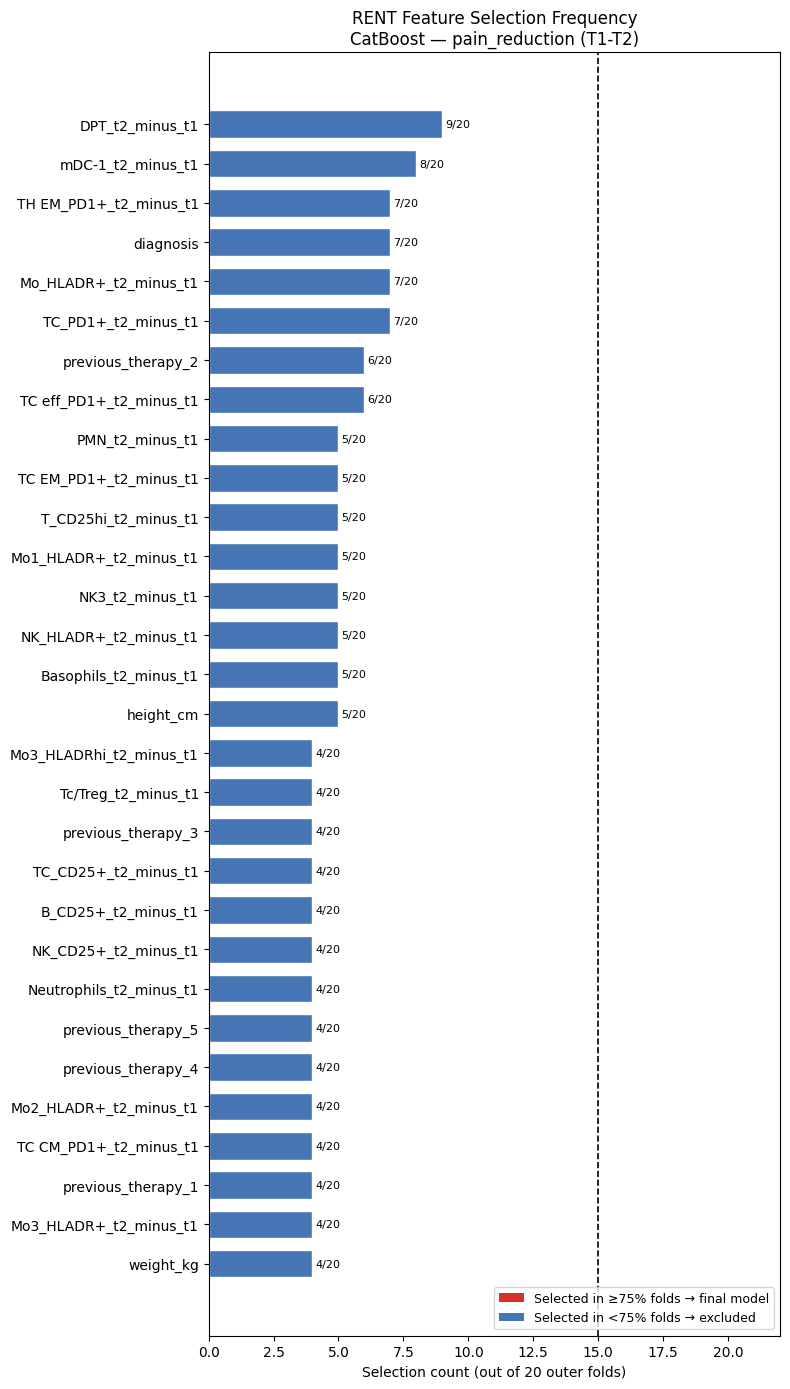


 SHAP — CatBoost (pain_reduction, T1-T2)

=== SHAP Analysis: CatBoost — pain_reduction (T1-T2) ===


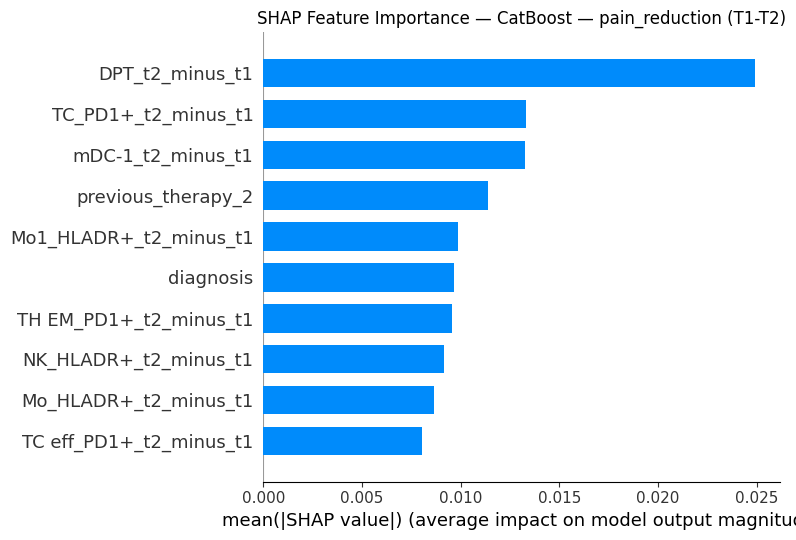

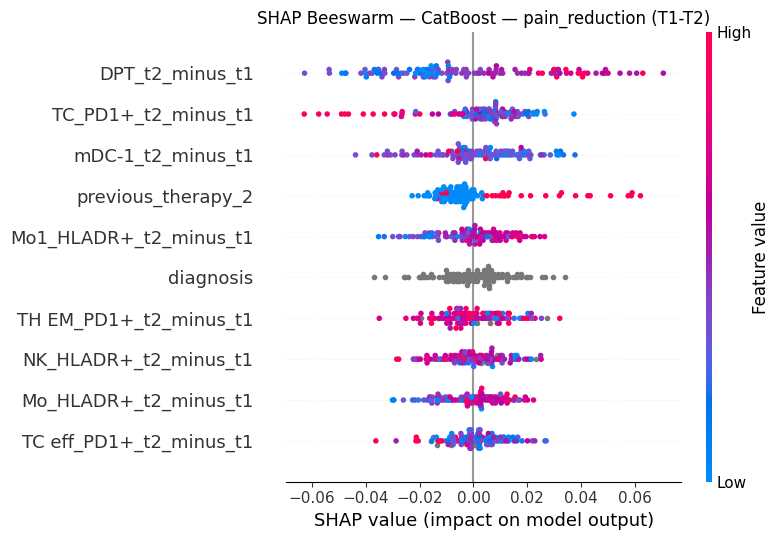

In [ ]:
# Plot Shap values
en2_model= joblib.load(os.path.join(MODEL_DIR, 'en2_model.pkl'))
en2_X_final = joblib.load(os.path.join(MODEL_DIR, 'en2_X_final.pkl'))
en2_scaler = joblib.load(os.path.join(MODEL_DIR, 'en2_scaler.pkl'))

en2_shap = model.plot_shap_elasticnet(en2_model, en2_X_final, en2_scaler)
